In [1]:
using Unitful 
using Plots
using Measures

gr()

Plots.GRBackend()

In [2]:
using Plots

## funziona corretta

In [3]:
min_pot = [0.9986997, 0.9978069, 0.9986706, 1.0009229, 0.9994534, 0.99822, 0.9980831, 0.998217, 0.99594384 ,0.99681985, 0.99802446, 0.99784315, 0.9977653, 0.9981247, 0.99690855]
grid_size = ["default",0.5u"mm", 0.45u"mm", 0.4u"mm", 0.35u"mm", 0.3u"mm", 0.25u"mm", 0.2u"mm", 0.15u"mm", 0.1u"mm", 0.05u"mm", 0.035u"mm", 0.03u"mm", 0.02u"mm", 0.01u"mm"]

15-element Vector{Any}:
  "default"
 0.5 mm
 0.45 mm
 0.4 mm
 0.35 mm
 0.3 mm
 0.25 mm
 0.2 mm
 0.15 mm
 0.1 mm
 0.05 mm
 0.035 mm
 0.03 mm
 0.02 mm
 0.01 mm

In [4]:
grod_wrong = ["0.02 mm"]
min_pot_wrong = [0.69480747]

1-element Vector{Float64}:
 0.69480747

In [5]:
using Statistics
r = min_pot ./ 1  # residui normlaizzati

res = min_pot .- 1              # residui centrati a 0
σ = std(res)                    # deviazione standard
res_σ = res ./ σ                # residui normalizzati in unità di sigma
var_pct = 100 .* (min_pot .- 1)

15-element Vector{Float64}:
 -0.1300300000000032
 -0.2193099999999948
 -0.1329400000000036
  0.09228999999999488
 -0.05465999999999527
 -0.17800000000000038
 -0.19168999999999992
 -0.1782999999999979
 -0.40561599999999753
 -0.3180150000000048
 -0.19755399999999979
 -0.2156849999999988
 -0.2234700000000034
 -0.18753000000000242
 -0.30914499999999956

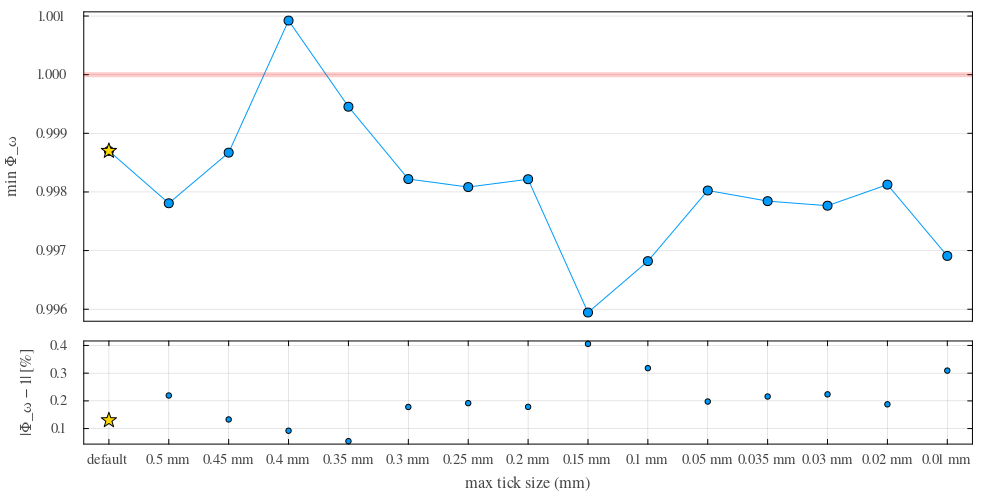

In [6]:
using Plots
using Colors

# Impostazioni "da paper"
default(
    fontfamily = "Times",
    guidefontsize = 10,
    tickfontsize = 9,
    legendfontsize = 9,
    titlefontsize = 10,
    lw = 1,
    ms = 5
)

x = 1:length(grid_size)
labels = string.(grid_size)



# Plot superiore
p1 = plot(
    x, min_pot;
    seriestype = :path,
    marker = :circle,
    markersize = 5,
    lw = 1,
    ylabel = "min Φ_ω",
    xticks = false,
    legend = false,
    framestyle = :box,
    grid = true,
    gridalpha = 0.1
)

hline!([1.0], linecolor = :red, lw =5 , alpha = 0.2, label = "Φ_ω = 1")
plot!( [x[1]], [min_pot[1]], seriestype = :scatter, marker = :star, markersize = 8, markercolor = :gold, )
# Plot inferiore
p2 = scatter(
    x,
    abs.(var_pct),
    ylabel = "|Φ_ω − 1| [%]",
    xticks = (x, labels),
    xlabel = "max tick size (mm)",
    legend = false,
    markersize = 3,
    top_margin = 0mm,
    bottom_margin = 5mm,
    left_margin = 8mm,
    right_margin = 5mm,
    framestyle = :box,
    grid = true,
    gridalpha = 0.1
)

plot!( [x[1]], [abs.(var_pct[1])], seriestype = :scatter, marker = :star, markersize = 8, markercolor = :gold, )
plot(
    p1,
    p2,
    layout = grid(
        2, 1,
        heights = [0.75, 0.25],
        hspace = 0mm
    ),
    link = :x, size = (1000, 500)
)


-------

## Usando solo 3 valori per il refinement sulla griglia

In [7]:
grid_3ref = [0.5u"mm", 0.45u"mm", 0.4u"mm", 0.35u"mm", 0.3u"mm", 0.25u"mm", 0.2u"mm", 0.15u"mm", 0.1u"mm", 0.05u"mm", 0.035u"mm"]
wp_min_3ref = [0.99746686, 0.99812055, 0.9983258, 0.99813133, 0.9965975, 0.99572974, 0.9987831, 0.9946135, 0.9969198,  0.9982532, 0.99608475]
min_pot_4step =  [0.9978069, 0.9986706, 1.0009229, 0.9994534, 0.99822, 0.9980831, 0.998217, 0.99594384  ,0.99681985,  0.99802446, 0.99784315]#  0.9977653,  0.9981247, 0.99690855]

11-element Vector{Float64}:
 0.9978069
 0.9986706
 1.0009229
 0.9994534
 0.99822
 0.9980831
 0.998217
 0.99594384
 0.99681985
 0.99802446
 0.99784315

In [8]:

var_pct_4s = 100 .* (min_pot_4step .- 1)
var_pct_3s = 100 .* (wp_min_3ref .- 1)

11-element Vector{Float64}:
 -0.2533140000000045
 -0.18794500000000047
 -0.1674199999999959
 -0.18686700000000167
 -0.3402499999999975
 -0.427025999999997
 -0.12168999999999652
 -0.5386499999999961
 -0.30801999999999774
 -0.17468000000000483
 -0.3915250000000037

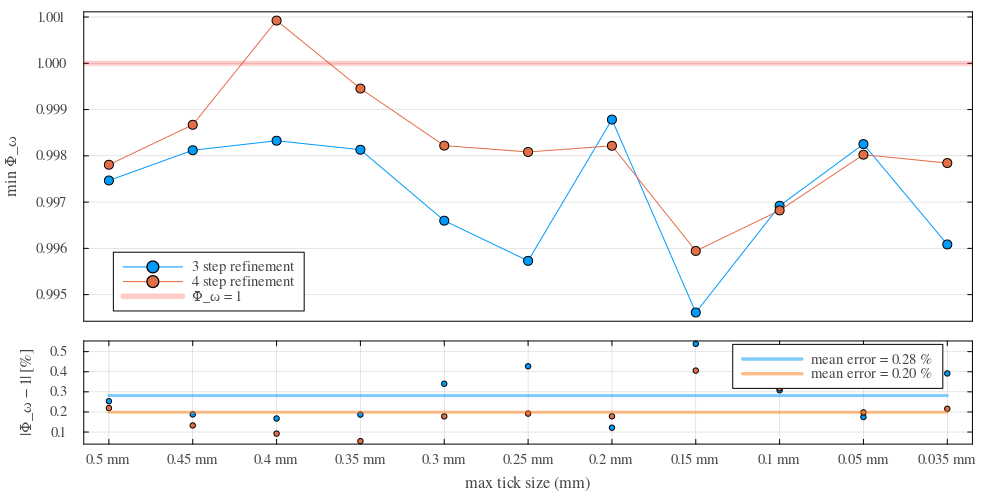

In [9]:
default(
    fontfamily = "Times",
    guidefontsize = 10,
    tickfontsize = 9,
    legendfontsize = 9,
    titlefontsize = 10,
    lw = 1,
    ms = 5
)

x = 1:length(grid_3ref)
labels = string.(grid_3ref)



# Plot superiore
p1 = plot(
    x, wp_min_3ref;
    seriestype = :path,
    marker = :circle,
    markersize = 5,
    xticks = false,
    lw = 1,
    ylabel = "min Φ_ω",
    legend = true,
    label = "3 step refinement",
framestyle = :box,
    grid = true,
    gridalpha = 0.1
)

plot!(x, min_pot_4step, seriestype = :path,
    marker = :circle,
    markersize = 5,
    lw = 1,
    label = "4 step refinement"  )

hline!([1.0], linecolor = :red, lw =5 , alpha = 0.2, label = "Φ_ω = 1")

p2 = scatter(
    x,
    abs.(var_pct_3s),
    ylabel = "|Φ_ω − 1| [%]",
    xticks = (x, labels),
    xlabel = "max tick size (mm)",
    legend = true,
    label = "",
    markersize = 3,
    top_margin = 0mm,
    bottom_margin = 5mm,
    left_margin = 8mm,
    right_margin = 5mm,
    framestyle = :box,
    grid = true,
    gridalpha = 0.1
)
scatter!(x, abs.(var_pct_4s),
    markersize = 3, label ="",
    )


using Printf

mean_val = mean(abs.(var_pct_3s))
mean_val_str = @sprintf("%.2f", mean_val)   # 2 cifre decimali
plot!([x[1], x[end]], [mean_val, mean_val];
      lw=3, alpha=0.5, color="#009BFA",
      label = "mean error = $mean_val_str %")

mean_val4S = mean(abs.(var_pct_4s))
mean_val4S_str = @sprintf("%.2f", mean_val4S)
plot!([x[1], x[end]], [mean_val4S, mean_val4S];
      lw=3, alpha=0.5, color="#FD7E14",
      label = "mean error = $mean_val4S_str %")

plot(
    p1,
    p2,
    layout = grid(
        2, 1,
        heights = [0.75, 0.25],
        hspace = 0mm
    ),
    link = :x, size = (1000, 500)
)

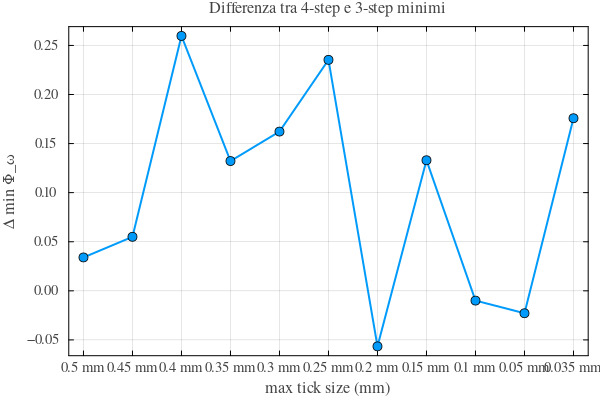

In [10]:
delta_pot = 100 .*(min_pot_4step .- wp_min_3ref)

# X asse: i punti principali della griglia (escludendo il gold)
x_main = 1:length(grid_3ref)   # come prima, le linee principali

# Plot della differenza
plot(
    x_main, delta_pot;
    seriestype = :path,
    marker = :circle,
    markersize = 5,
    lw = 2,
    xlabel = "max tick size (mm)",
    xticks = (x_main, string.(grid_3ref[x_main])),
    ylabel = "Δ min Φ_ω",
    title = "Differenza tra 4-step e 3-step minimi",
    grid = true,
    gridalpha = 0.1,
    legend = false,
    framestyle = :box
)

## Funzione totale


nella scrittura della funzione 'globale' vi sono dei parametri che sono più ottimizzati di quelli che uso io nella funzione a "pezzi". Questo potrebbe portare ad un miglioramento del minimo (anched dell'ordine di 1x1000)

In [12]:
using HDF5


In [13]:

filename = "/home/ritaferi/Phd/SSDdev/saved_results_new_function/simulation_with_4_jumps.h5"
min_pot_4   = Float64[]
run_time_4  = Float64[]
grid_dict      = Float64[]

h5open(filename, "r") do f
    for gridname in keys(f)
        g = f[gridname]

        # estrai il numero da "grid_0.5mm" → 0.5
        grid_val = parse(Float64, replace(gridname, "grid_" => "", "mm" => ""))

        push!(run_time_4, read(g["time_s"]))
        push!(min_pot_4,   read(g["min_weighting_potential"]))
        push!(grid_dict, grid_val)
    end
end
using StatsBase  # per `sortperm`, ma puoi anche usare Base

perm = sortperm(grid_dict, rev=true)

grid_dict     = grid_dict[perm]
run_time_4 = run_time_4[perm]
min_pot_4  = min_pot_4[perm]

println("Griglie ordinate decrescente: ", grid_dict)
println("run_time = ", run_time_4)
println("min_pot  = ", min_pot_4)

Griglie ordinate decrescente: [0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1, 0.05]
run_time = [41.223147658, 50.100006559, 51.341915195, 58.926578769, 65.942530896, 83.584181274, 111.522990909, 193.933137598, 414.221141991, 1719.346088194]
min_pot  = [0.9983900189399719, 0.9992566704750061, 0.9991686344146729, 0.9997855424880981, 0.9988164901733398, 0.9987534284591675, 0.9987296462059021, 0.9940186142921448, 0.997744083404541, 0.9989195466041565]


In [14]:

filename = "/home/ritaferi/Phd/SSDdev/saved_results_new_function/simulation_with_3_jumps.h5"
min_pot_3  = Float64[]
run_time_3  = Float64[]
grid_dict      = Float64[]

h5open(filename, "r") do f
    for gridname in keys(f)
        g = f[gridname]

        # estrai il numero da "grid_0.5mm" → 0.5
        grid_val = parse(Float64, replace(gridname, "grid_" => "", "mm" => ""))

        push!(run_time_3, read(g["time_s"]))
        push!(min_pot_3,   read(g["min_weighting_potential"]))
        push!(grid_dict, grid_val)
    end
end
using StatsBase  # per `sortperm`, ma puoi anche usare Base

perm = sortperm(grid_dict, rev=true)

grid_dict     = grid_dict[perm]
run_time_3 = run_time_3[perm]
min_pot_3  = min_pot_3[perm]

println("Griglie ordinate decrescente: ", grid_dict)
println("run_time = ", run_time_3)
println("min_pot  = ", min_pot_3)


Griglie ordinate decrescente: [0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1, 0.05]
run_time = [36.076415281, 40.228181764, 44.518824767, 55.991538021, 60.127595252, 77.697939655, 109.44523269, 180.388453008, 351.595350108, 1646.933506327]
min_pot  = [0.9984800815582275, 0.9991684556007385, 0.9990437626838684, 0.9987965226173401, 0.9979878067970276, 0.9983296394348145, 0.9986293911933899, 0.9957297444343567, 0.9981324076652527, 0.9972745776176453]


In [15]:

filename = "/home/ritaferi/Phd/SSDdev/saved_results_new_function/simulation_with_2_jumps.h5"
min_pot_2  = Float64[]
run_time_2  = Float64[]
grid_dict      = Float64[]

h5open(filename, "r") do f
    for gridname in keys(f)
        g = f[gridname]

        # estrai il numero da "grid_0.5mm" → 0.5
        grid_val = parse(Float64, replace(gridname, "grid_" => "", "mm" => ""))

        push!(run_time_2, read(g["time_s"]))
        push!(min_pot_2,   read(g["min_weighting_potential"]))
        push!(grid_dict, grid_val)
    end
end
using StatsBase  # per `sortperm`, ma puoi anche usare Base

perm = sortperm(grid_dict, rev=true)

grid_dict     = grid_dict[perm]
run_time_2 = run_time_2[perm]
min_pot_2  = min_pot_2[perm]

println("Griglie ordinate decrescente: ", grid_dict)
println("run_time = ", run_time_2)
println("min_pot  = ", min_pot_2)


Griglie ordinate decrescente: [0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1, 0.05]
run_time = [50.117921328, 44.7187884, 49.526937062, 58.165455611, 65.074084882, 81.911904187, 110.348351454, 155.921428674, 346.160334739, 1342.411458676]
min_pot  = [0.9983182549476624, 0.998266875743866, 0.9970980882644653, 0.998015284538269, 0.997593879699707, 0.9976626634597778, 0.9992419481277466, 0.9970499277114868, 0.9970728754997253, 0.9976280927658081]


In [16]:

filename = "/home/ritaferi/Phd/SSDdev/saved_results_new_function/simulation_with_1_jumps.h5"
min_pot_1  = Float64[]
run_time_1  = Float64[]
grid_dict      = Float64[]

h5open(filename, "r") do f
    for gridname in keys(f)
        g = f[gridname]

        # estrai il numero da "grid_0.5mm" → 0.5
        grid_val = parse(Float64, replace(gridname, "grid_" => "", "mm" => ""))

        push!(run_time_1, read(g["time_s"]))
        push!(min_pot_1,   read(g["min_weighting_potential"]))
        push!(grid_dict, grid_val)
    end
end
using StatsBase  # per `sortperm`, ma puoi anche usare Base

perm = sortperm(grid_dict, rev=true)

grid_dict     = grid_dict[perm]
run_time_1 = run_time_1[perm]
min_pot_1  = min_pot_1[perm]

println("Griglie ordinate decrescente: ", grid_dict)
println("run_time = ", run_time_1)
println("min_pot  = ", min_pot_1)


Griglie ordinate decrescente: [0.5, 0.45, 0.4, 0.35, 0.3, 0.25, 0.2, 0.15, 0.1, 0.05]
run_time = [35.235055139, 36.255754274, 39.630376626, 49.107911964, 50.433244669, 64.437802217, 77.420487962, 115.873867319, 232.714871208, 1054.957632024]
min_pot  = [0.9979243874549866, 0.9975264072418213, 1.0000865459442139, 1.0018491744995117, 0.9976038932800293, 0.9973247647285461, 0.998015820980072, 0.9973329305648804, 0.9977616667747498, 0.9940540194511414]


In [18]:
grid_comp = [0.5u"mm", 0.45u"mm", 0.4u"mm", 0.35u"mm", 0.3u"mm", 0.25u"mm", 0.2u"mm", 0.15u"mm", 0.1u"mm", 0.05u"mm"]

10-element Vector{Quantity{Float64, 𝐋, Unitful.FreeUnits{(mm,), 𝐋, nothing}}}:
 0.5 mm
 0.45 mm
 0.4 mm
 0.35 mm
 0.3 mm
 0.25 mm
 0.2 mm
 0.15 mm
 0.1 mm
 0.05 mm

In [19]:
var_4 = 100 .* abs.((min_pot_4 .- 1))
var_3 = 100 .* abs.((min_pot_3 .- 1))
var_2 = 100 .* abs.((min_pot_2 .- 1))
var_1 = 100 .* abs.((min_pot_1 .- 1))


10-element Vector{Float64}:
 0.20756125450134277
 0.2473592758178711
 0.008654594421386719
 0.18491744995117188
 0.2396106719970703
 0.26752352714538574
 0.19841790199279785
 0.2667069435119629
 0.22383332252502441
 0.5945980548858643

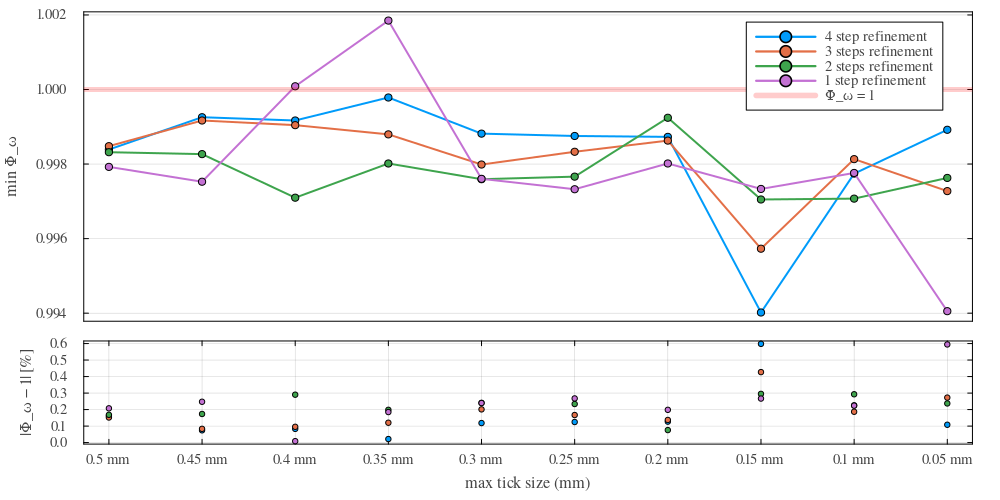

In [20]:
default(
    fontfamily = "Times",
    guidefontsize = 10,
    tickfontsize = 9,
    legendfontsize = 9,
    titlefontsize = 10,
    lw = 1,
    ms = 5
)

x = 1:length(grid_comp)
labels = string.(grid_comp)



# Plot superiore
p1 = plot(
    x, min_pot_4;
    seriestype = :path,
    marker = :circle,
    markersize = 4,
    xticks = false,
    lw = 2,
    ylabel = "min Φ_ω",
    legend = true,
    label = "4 step refinement",
framestyle = :box,
    grid = true,
    gridalpha = 0.1
)

 plot!(
    x, min_pot_3;
    seriestype = :path,
    lw = 2,
    marker = :circle,
    markersize = 4,
    label = "3 steps refinement",)

    
 plot!(
    x, min_pot_2;
    lw = 2,
    seriestype = :path,
    marker = :circle,
    markersize = 4,
    label = "2 steps refinement",)

 plot!(
    x, min_pot_1;
    seriestype = :path,
    marker = :circle,
    lw = 2,
    markersize = 4,
    label = "1 step refinement",)

hline!([1.0], linecolor = :red, lw =5 , alpha = 0.2, label = "Φ_ω = 1")

p2 = scatter(
    x,
    abs.(var_4),
    ylabel = "|Φ_ω − 1| [%]",
    xticks = (x, labels),
    xlabel = "max tick size (mm)",
    legend = true,
    label = "",
    markersize = 3,
    top_margin = 0mm,
    bottom_margin = 5mm,
    left_margin = 8mm,
    right_margin = 5mm,
    framestyle = :box,
    grid = true,
    gridalpha = 0.1
)

scatter!(
    x,
    abs.(var_3),
    markersize = 3,
    label = "")
scatter!(
    x,
    abs.(var_2),
    markersize = 3,
    label = "")
scatter!(
    x,
    abs.(var_1),
    markersize = 3,
    label = "")

p = plot(
    p1,
    p2,
    layout = grid(
        2, 1,
        heights = [0.75, 0.25],
        hspace = 0mm
    ),
    link = :x, size = (1000, 500)
)
savefig(p, "comparison_ref_jump.png")

display(p)

In [21]:
println("mean error 1 jump  $(mean(abs.(var_1))) %")
println("mean error 2 jumps  $(mean(abs.(var_2))) %" )
println("mean error 3 jumps  $(mean(abs.(var_3))) %")
println("mean error 4 jumps  $(mean(abs.(var_4))) %")

println("max error 1 jump  $(maximum(abs.(var_1))) %")
println("max error 2 jump  $(maximum(abs.(var_2))) %" )
println("max error 3 jump  $(maximum(abs.(var_3))) %")
println("max error 4 jump  $(maximum(abs.(var_4))) %")

mean error 1 jump  0.2439182996749878 %
mean error 2 jumps  0.22052109241485596 %
mean error 3 jumps  0.18427610397338867 %
mean error 4 jumps  0.16417324542999268 %
max error 1 jump  0.5945980548858643 %
max error 2 jump  0.29500722885131836 %
max error 3 jump  0.42702555656433105 %
max error 4 jump  0.5981385707855225 %


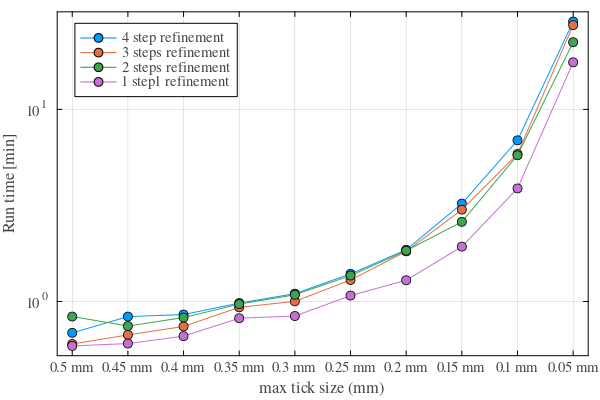

In [22]:
default(
    fontfamily = "Times",
    guidefontsize = 10,
    tickfontsize = 9,
    legendfontsize = 9,
    titlefontsize = 10,
    lw = 1,
    ms = 5
)

y_max = ceil(Int, maximum([run_time_4; run_time_3]) / 60)  # massima y arrotondata
yticks_vals = 0:2:y_max  # tick ogni 2 minuti

x = 1:length(grid_comp)
labels = string.(grid_comp)



# Plot superiore
p = plot(
    x, run_time_4 ./60;
    seriestype = :path,
    marker = :circle,
    markersize = 5,
    xticks = (x, labels),
    xlabel = "max tick size (mm)",
    lw = 1,
    ylabel = "Run time [min]",
    legend = true,
    label = "4 step refinement",
framestyle = :box,
    grid = true,
    gridalpha = 0.1,
    yscale = :log10
)

plot!(
    x, run_time_3 ./60;
    seriestype = :path,
    marker = :circle,
    markersize = 5,
    label = "3 steps refinement")

    
plot!(
    x, run_time_2 ./60;
    seriestype = :path,
    marker = :circle,
    markersize = 5,
    label = "2 steps refinement")

plot!(
    x, run_time_1 ./60;
    seriestype = :path,
    marker = :circle,
    markersize = 5,
    label = "1 step1 refinement")

savefig(p, "time_comparison_ref_jump_log.png")
display(p)